# Assignment Module 2: Pet Classification

The goal of this assignment is to implement a neural network that classifies images of 37 breeds of cats and dogs from the [Oxford-IIIT-Pet dataset](https://www.robots.ox.ac.uk/~vgg/data/pets/). The assignment is divided into two parts: first, you will be asked to implement from scratch your own neural network for image classification; then, you will fine-tune a pretrained network provided by PyTorch.

### Notebook Mode: Training or Loading
Set this global variable to True is the training has to be done and to False is the training has already been done and you only want to load the model weights.

In [1]:
TRAINING_REQUIRED = False

model_weights_links = {
    "model_B":"https://drive.google.com/file/d/1Bq8-yj911YcUFkVLIgMSK65zA2-dTPQW/view?usp=sharing",
    "model_C":"https://drive.google.com/file/d/19eRybLj7AlyKlzlWDTw7LRu8Cv1SSPqc/view?usp=sharing",
    "model_D":"https://drive.google.com/file/d/1gayQ-0ZQvj6Mov6AucrkNRpJwLXq_TAk/view?usp=sharing",
    "model_E":"https://drive.google.com/file/d/1dRgjhUgGTnaZsbd4J80hablaQQCnB1Fu/view?usp=sharing",
    "model_F":"https://drive.google.com/file/d/1ggGcb8udUYACl9BLPygnGjKltg4QPmUZ/view?usp=sharing",
    "model_G":"https://drive.google.com/file/d/1cNqpCfg5ApOK25_d9VaIU4qudmq5Kehp/view?usp=sharing",
    "model_H":"https://drive.google.com/file/d/1n9BqTySpvaBWgDwgrNy78c80DlxG2-Qu/view?usp=sharing",
    "model_2A":"https://drive.google.com/file/d/1iopBKK2rwnZat8qryqIufPJyMr8AImFy/view?usp=sharing",
    "model_2B":"https://drive.google.com/file/d/1iT01t3pkd8dXa4CvEbT0ivI00h82tcmN/view?usp=sharing"
}

model_history_links = {
    "history_B":"https://drive.google.com/file/d/13Hq_W4A34XZ9_4tiBzcf3V2mMS8Pmkcn/view?usp=sharing",
    "history_C":"https://drive.google.com/file/d/17YJGryGHa5rl--TidHdN1-dE_t96p9ZK/view?usp=sharing",
    "history_D":"https://drive.google.com/file/d/1RAJvYzKOQ10yv1Wz-ddC8GdBCnXOtjFv/view?usp=sharing",
    "history_E":"https://drive.google.com/file/d/1fUVYfubdkqbSvXGQ63b8dBDnJ1PlkMWB/view?usp=sharing",
    "history_F":"https://drive.google.com/file/d/1xKNjXOim1T5n4o61skNJxnaNCje30xIO/view?usp=sharing",
    "history_G":"https://drive.google.com/file/d/1ahkYCSvK6tlywQVQMXBEF38c00oMJpvc/view?usp=sharing",
    "history_H":"https://drive.google.com/file/d/17DC7tl5wKeZGbKU4qxwjjUAlZWnljroc/view?usp=sharing",
    "history_2A":"https://drive.google.com/file/d/16sx2O2OKQCNWsKcHjg25PQPv9Qm1ncj3/view?usp=sharing",
    "history_2B":"https://drive.google.com/file/d/1PoBRts9_rC3hGP9VZHuslZURVCDL8Nvx/view?usp=sharing"
}

#we create a dictionary to store the performance metrics which we'll plot at the end
models_performance = {}

### Import

In [ ]:
!git clone https://github.com/CVLAB-Unibo/ipcv-assignment-2.git

In [ ]:
!pip install -q wandb
!pip install -q torchmetrics
!pip install -q torchinfo

In [ ]:
from pathlib import Path
from PIL import Image
from torch import Tensor
from torch.utils.data import Dataset
from typing import Any, Callable, Dict, List, Optional, Tuple
import random
import time
import matplotlib.pyplot as plt
import numpy as np
from tqdm.notebook import tqdm
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam, AdamW
from torch.utils.data import random_split, DataLoader
from torchvision import transforms as T, datasets
import torchvision.transforms.v2 as v2
from torch.optim.lr_scheduler import OneCycleLR, ReduceLROnPlateau, CosineAnnealingLR,SequentialLR, LinearLR
from torchmetrics.classification.accuracy import Accuracy
import copy
from torchvision.models import resnet18, ResNet18_Weights
import wandb
import gdown
import os
import json
from torchinfo import summary
import matplotlib.pyplot as plt

print("Using torch", torch.__version__)

### Dataset

The following cells contain the code to download and access the dataset you will be using in this assignment. Note that, although this dataset features each and every image from [Oxford-IIIT-Pet](https://www.robots.ox.ac.uk/~vgg/data/pets/), it uses a different train-val-test split than the original authors.

In [5]:
class OxfordPetDataset(Dataset):
    def __init__(self, split: str, transform=None) -> None:
        super().__init__()

        self.root = Path("ipcv-assignment-2") / "dataset"
        self.split = split
        self.names, self.labels = self._get_names_and_labels()
        self.transform = transform

    def __len__(self) -> int:
        return len(self.labels)

    def __getitem__(self, idx) -> Tuple[Tensor, int]:
        img_path = self.root / "images" / f"{self.names[idx]}.jpg"
        img = Image.open(img_path).convert("RGB")
        label = self.labels[idx]

        if self.transform:
            img = self.transform(img)

        return img, label

    def get_num_classes(self) -> int:
        return max(self.labels) + 1

    def _get_names_and_labels(self) -> Tuple[List[str], List[int]]:
        names = []
        labels = []

        with open(self.root / "annotations" / f"{self.split}.txt") as f:
            for line in f:
                name, label = line.replace("\n", "").split(" ")
                names.append(name),
                labels.append(int(label) - 1)

        return names, labels

In [6]:
def get_dataloaders(train_transformer,test_transformer, batch_size):

    #   Datasets  
    train_dset = OxfordPetDataset(
        split="train",
        transform=train_transformer
    )
    val_dset = OxfordPetDataset(
        split="val",
        transform=test_transformer,
    )
    test_dset = OxfordPetDataset(
        split="test",
        transform=test_transformer,
    )

    #   DataLoaders  
    train_dl = DataLoader(
        train_dset,
        batch_size=batch_size,
        shuffle=True
    )
    val_dl = DataLoader(
        val_dset,
        batch_size=batch_size
    )
    test_dl = DataLoader(
        test_dset,
        batch_size=batch_size
    )

    return train_dl, val_dl, test_dl

### Fix randomness

In [7]:
def fix_random(seed: int) -> None:
    """Fix all the possible sources of randomness.

    Args:
        seed: the seed to use.
    """
    np.random.seed(seed)
    random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)

    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True

fix_random(33)

### GPU check

In [8]:
gpu_avail = torch.cuda.is_available()
print(f"Is the GPU available? {gpu_avail}")

device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
print(f"Device: {device}")

Is the GPU available? True
Device: cuda


### Free memory

In [9]:
import gc

torch.cuda.empty_cache()
gc.collect()

289

### Trainer class
This class is the trainer that was used for both the training and the finetuning of our models.


In [10]:
from time import time

class Trainer:
    def __init__(self,
                 model: nn.Module,
                 train_loader: DataLoader,
                 val_loader: DataLoader,
                 test_loader: DataLoader,
                 device: torch.device,
                 model_file_name: str,
                 num_classes: int,
                 cfg: Dict[str, Any],
                 wandb_credentials: Optional[Tuple[str, str]] = None,
                 verbose: bool = False,
                 ) -> None:

        # Loaders
        self.train_loader = train_loader
        self.val_loader = val_loader
        self.test_loader = test_loader

        # Model to device
        self.device = device
        self.model = model.to(device)
        self.best_model = copy.deepcopy(self.model)
        self.best_state_dict = copy.deepcopy(self.model.state_dict())
        self.model_file_name = model_file_name

        # Classes
        self.num_classes = num_classes

        # Epochs
        self.num_epochs = cfg["num_epochs"]

        # Optimizer
        self.optimizer = AdamW(self.model.parameters(), lr=cfg["lr"], weight_decay=cfg["wd"])

        # Scheduler
        if cfg["scheduler"]:
            num_steps = self.num_epochs * len(train_loader)
            self.scheduler = OneCycleLR(self.optimizer, cfg["lr"], total_steps=num_steps)
        else:
            # Dummy scheduler
            from torch.optim.lr_scheduler import LambdaLR
            self.scheduler = LambdaLR(self.optimizer, lr_lambda=lambda epoch: 1.0)

        # Label Smoothing 
        self.label_smoothing = cfg['label_smoothing']

        # Batch transformations (MixUp, CutMix, ...)
        self.batch_transforms = cfg["batch_transforms"]

        # Stats
        self.step = 0
        self.best_acc = 0.0
        self.train_loss = []
        self.train_acc = []
        self.val_loss = []
        self.val_acc = []

        # Wandb credentials
        self.wandb_credentials = wandb_credentials
        if self.wandb_credentials is not None:
          WANDB_USER, WANDB_PROJECT = self.wandb_credentials
          wandb.init(name=cfg["run_name"], entity=WANDB_USER, project=WANDB_PROJECT, config=cfg)

        # Path for saving model
        self.ckpt_path = Path("ckpts")
        self.ckpt_path.mkdir(exist_ok=True)

        # Verbose
        self.verbose = verbose

    def logfn(self, values: Dict[str, Any]) -> None:
        wandb.log(values, step=self.step, commit=False)

    def train(self) -> None:
        for _ in tqdm(range(self.num_epochs), desc="Epoch"):
            self.model.train()

            running_losses = []
            correct = 0
            total = 0  

            for imgs, labels in self.train_loader:
                imgs = imgs.to(self.device)
                labels = labels.to(self.device)

                if self.batch_transforms:
                  imgs, labels = self.batch_transforms(imgs, labels)

                pred = self.model(imgs)
                loss = F.cross_entropy(pred, labels, label_smoothing=self.label_smoothing)

                self.optimizer.zero_grad()
                loss.backward()
                self.optimizer.step()
                self.scheduler.step()

                if self.wandb_credentials:
                    self.logfn({"train/loss": loss.item()})
                    self.logfn({"train/lr": self.scheduler.get_last_lr()[0]})

                self.step += 1

                running_losses.append(loss.item())
                
                preds = pred.argmax(dim=-1)

                if labels.ndim > 1:
                    labels = labels.argmax(dim=-1)
                
                correct += (preds == labels).sum().item()
                batch_size = labels.size(0) if labels.ndim > 0 else 1
                total += batch_size

            train_loss =  sum(running_losses) / len(running_losses)
            train_accuracy = correct / total

            if self.verbose:
                print(f"Epoch {_+1}")
                print(f"\ttrain loss {train_loss:.3f} - train accuracy {train_accuracy:.3f}")

            val_loss, val_accuracy = self.eval("val")

            if self.verbose:
                print(f"\tval loss {val_loss:.3f} - val accuracy {val_accuracy:.3f}")

            self.train_loss.append(train_loss)
            self.train_acc.append(train_accuracy)
            self.val_loss.append(val_loss)
            self.val_acc.append(val_accuracy)

        if self.wandb_credentials:
          wandb.finish()

    @torch.no_grad()
    def eval(self, split: str) -> Tuple[float, float]:
    
        if split == "test":
            self.best_model.load_state_dict(self.best_state_dict)
            model_to_eval = self.best_model

        else:
            model_to_eval = self.model
    
        model_to_eval.eval()
    
        loader = (
            self.train_loader if split == "train"
            else self.val_loader if split == "val"
            else self.test_loader
        )
    
        losses = []
        correct = 0
        total = 0
    
        for imgs, labels in loader:
            imgs = imgs.to(self.device)
            labels = labels.to(self.device)
    
            pred = model_to_eval(imgs)
            loss = F.cross_entropy(pred, labels, label_smoothing=self.label_smoothing)
            losses.append(loss.item())

            preds = pred.argmax(dim=-1)
        
            correct += (preds == labels).sum().item()

            total += labels.size(0)
    
        loss = sum(losses) / len(losses)
        accuracy = correct / total
    
        if self.wandb_credentials:
            self.logfn({f"{split} loss": loss})
            self.logfn({f"{split} acc": accuracy})

        if accuracy > self.best_acc and split == "val":
            self.best_acc = accuracy
            self.best_state_dict = copy.deepcopy(model_to_eval.state_dict())
            if self.wandb_credentials:
                torch.save(self.best_state_dict, self.ckpt_path / f"{wandb.run.name}.pth")
            else:
                torch.save(self.best_state_dict, self.ckpt_path / f"{self.model_file_name}.pth")
    
        return loss, accuracy

    def load(self, path: str, model_name: str = None):
        
        if not os.path.exists(path):
            if model_name is None or model_name not in model_weights_links:
                raise FileNotFoundError(f"File {path} not found and no valid model name provided.")
            
            os.makedirs(os.path.dirname(path), exist_ok=True)

            url = model_weights_links[model_name]
            file_id = url.split("/d/")[1].split("/")[0]
            gdown.download(f"https://drive.google.com/uc?id={file_id}", path, quiet=False)

        self.best_state_dict = torch.load(path)
        self.model.load_state_dict(self.best_state_dict)

    def save_history(self):
        history = {
            "train_loss":self.train_loss,
            "train_acc":self.train_acc,
            "val_loss":self.val_loss,
            "val_acc":self.val_acc
        }
    
        folder = "plots"
        file_path = os.path.join(folder, self.model_file_name+".json")
        os.makedirs(folder, exist_ok=True)

        with open(file_path, "w") as f:
            json.dump(history, f, indent=4)

    def fine_tune(self, unfreeze_schedule: Dict[int, List[nn.Module]]) -> None:
        
        for epoch in tqdm(range(1, self.num_epochs + 1), desc="Epoch"):
            # Check unfreeze schedule
            if epoch in unfreeze_schedule:
                layers_to_unfreeze = unfreeze_schedule[epoch]
                for layer in layers_to_unfreeze:
                    for param in layer.parameters():
                        param.requires_grad = True
                if self.verbose:
                    unfrozen_names = [layer.__class__.__name__ for layer in layers_to_unfreeze]
                    print(f"\n[Epoch {epoch}] Unfroze layers: {unfrozen_names}")

                # Reinitialize optimizer with updated trainable params
                trainable_params = [p for p in self.model.parameters() if p.requires_grad]
                self.optimizer = type(self.optimizer)(trainable_params, **self.optimizer.defaults)
                if self.verbose:
                    print(f"Optimizer reinitialized with {len(trainable_params)} trainable parameter groups")

            # Training phase
            self.model.train()
            running_losses = []
            correct, total = 0, 0

            for imgs, labels in self.train_loader:
                imgs, labels = imgs.to(self.device), labels.to(self.device)

                if self.batch_transforms:
                    imgs, labels = self.batch_transforms(imgs, labels)

                pred = self.model(imgs)
                loss = F.cross_entropy(pred, labels, label_smoothing=self.label_smoothing)

                self.optimizer.zero_grad()
                loss.backward()
                self.optimizer.step()
                self.scheduler.step()

                if self.wandb_credentials:
                    self.logfn({"train/loss": loss.item()})
                    self.logfn({"train/lr": self.scheduler.get_last_lr()[0]})

                self.step += 1
                running_losses.append(loss.item())

                preds = pred.argmax(dim=-1)
                if labels.ndim > 1:
                    labels = labels.argmax(dim=-1)
                correct += (preds == labels).sum().item()
                total += labels.size(0)

            train_loss = sum(running_losses) / len(running_losses)
            train_acc = correct / total

            val_loss, val_acc = self.eval("val")

            if self.verbose:
                print(f"Epoch {epoch}: train loss {train_loss:.3f}, train acc {train_acc:.3f}, "
                      f"val loss {val_loss:.3f}, val acc {val_acc:.3f}")

            self.train_loss.append(train_loss)
            self.train_acc.append(train_acc)
            self.val_loss.append(val_loss)
            self.val_acc.append(val_acc)

        if self.wandb_credentials:
            wandb.finish()

### Plot the history
Function to plot the loss and accuracy evolution as training progresses.

In [11]:
def plot_history(history):

  fig, axes = plt.subplots(1, 2, figsize=(10,4))

  # Loss
  axes[0].plot(history["train_loss"], label="train")
  if history["val_loss"]:
      axes[0].plot(history["val_loss"], label="val")
  axes[0].set_title("Loss")
  axes[0].legend()

  # Accuracy
  axes[1].plot(history["train_acc"], label="train")
  if history["val_acc"]:
      axes[1].plot(history["val_acc"], label="val")
  axes[1].set_title("Top-1 Accuracy")
  axes[1].legend()

  plt.tight_layout()
  plt.show()

### Load the history
Utility function.

In [12]:
def load_history(path: str, history_name: str = None):
        
    if not os.path.exists(path):
        if history_name is None or history_name not in model_history_links:
            raise FileNotFoundError(f"File {path} not found and no valid model name provided.")

        dir_path = os.path.dirname(path)
        if dir_path:
            os.makedirs(dir_path, exist_ok=True)

        url = model_history_links[history_name]
        file_id = url.split("/d/")[1].split("/")[0]
        gdown.download(f"https://drive.google.com/uc?id={file_id}", path, quiet=False)

    with open(path, "r") as f:
        history_loaded = json.load(f)

    return history_loaded

# Part 1: design your own network

Your goal is to implement a convolutional neural network for image classification and train it from scratch on `OxfordPetDataset`. You should consider yourselves satisfied once you obtain a classification accuracy on the test split of ~60%. You are free to achieve this however you want, except for a few rules you must follow:

- Compile this notebook by displaying the results obtained by the best model you found throughout your experimentation; then show how, by removing some of its components, its performance drops. In other words, do an *ablation study* to prove that your design choices have a positive impact on the final result.

- Do not instantiate an off-the-self PyTorch network. Instead, construct your network as a composition of existing PyTorch layers. In more concrete terms, you can use e.g. `torch.nn.Linear`, but you cannot use e.g. `torchvision.models.alexnet`.

- Show your results and ablations with plots, tables, images, etc. — the clearer, the better.

Don't be too concerned with your model performance: the ~60% is just to give you an idea of when to stop. Keep in mind that a thoroughly justified model with lower accuracy will be rewarded more points than a poorly experimentally validated model with higher accuracy.

### CNN Architecture

We created a CNN inspired to the Res-Net architecture.

We created multiple types of blocks, with different levels of complexity:

- the **BatchNormBlock**: conv + BN + ReLU.
- the **ResidualBlock**: conv + BN + ReLU + skip connections.
- the **BottleneckBlock**: conv + BN + ReLU + skip connections + bottleneck (compression + conv + expansion).

In [13]:
class BatchNormBlock(nn.Module): #basic convolutional block + batch normalization

    expansion = 1
    uses_residual = False

    def __init__(self, in_channels, out_channels, stride=1, downsample=None):
        super(BatchNormBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride,
                               padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1,
                               padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.downsample = downsample

    def forward(self, x):

        out = self.conv1(x)
        out = self.bn1(out)
        out = torch.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)
        out = torch.relu(out)
        
        return out
    

class ResidualBlock(nn.Module): #also skip connections
    expansion = 1
    uses_residual = True
    
    def __init__(self, in_channels, out_channels, stride=1, downsample=None):
        super(ResidualBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride,
                               padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1,
                               padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.downsample = downsample

    def forward(self, x):
        identity = x

        out = torch.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))

        if self.downsample is not None:
            identity = self.downsample(x)

        out += identity
        out = torch.relu(out)
        return out


class Bottleneck(nn.Module): #also bottleneck
    expansion = 4
    uses_residual = True

    def __init__(self, in_channels, out_channels, stride=1, downsample=None):
        super(Bottleneck, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels // self.expansion, kernel_size=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels // self.expansion)
        self.conv2 = nn.Conv2d(out_channels // self.expansion, out_channels // self.expansion, kernel_size=3, stride=stride,
                               padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels // self.expansion)
        self.conv3 = nn.Conv2d(out_channels // self.expansion, out_channels, kernel_size=1, bias=False)
        self.bn3 = nn.BatchNorm2d(out_channels)
        self.downsample = downsample

    def forward(self, x):
        identity = x

        out = torch.relu(self.bn1(self.conv1(x)))
        out = torch.relu(self.bn2(self.conv2(out)))
        out = self.bn3(self.conv3(out))

        if self.downsample is not None:
            identity = self.downsample(x)

        out += identity
        out = torch.relu(out)
        return out


class CNN(nn.Module): #this defines the CNN with the desired type of blocks 
    def __init__(self, block, layers, num_classes=37, input_channels=3, dropout=0.5):
        super(CNN, self).__init__()
        self.in_channels = 64
        self.block = block

        # Initial stem
        self.conv1 = nn.Conv2d(input_channels, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)

        # Residual layers
        self.layer1 = self._make_layer(64, layers[0], stride=1)
        self.layer2 = self._make_layer(128, layers[1], stride=2)
        self.layer3 = self._make_layer(256, layers[2], stride=2)
        self.layer4 = self._make_layer(512, layers[3], stride=2)

        # Adaptive pooling for variable input size
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.dropout = nn.Dropout(p=dropout)
        self.fc = nn.Linear(512 * block.expansion, num_classes)

    def _make_layer(self, out_channels, blocks, stride=1):
        downsample = None
        
        # Downsample if stride > 1 or if input/output channels differ
        if stride != 1 or self.in_channels != out_channels * self.block.expansion:
            downsample = nn.Sequential(
                nn.Conv2d(self.in_channels, out_channels * self.block.expansion,
                          kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels * self.block.expansion),
            )

        layers = []
        layers.append(self.block(self.in_channels, out_channels * self.block.expansion, stride, downsample))
        self.in_channels = out_channels * self.block.expansion

        for _ in range(1, blocks):
            layers.append(self.block(self.in_channels, out_channels * self.block.expansion))

        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.dropout(x)
        x = self.fc(x)

        return x

## Model B: best model

**Architecture**:

- The number of blocks for each layer is: **[2,3,4,2]**
- We use **ResidualBlock**

**Regularization** and **training recipes**:

- dropout
- weight decay
- scheduler
- trivial augmentation
- input normalization
- mixup
- cutmix
- random erasing



Layer (type:depth-idx)                   Param #
CNN                                      --
├─Conv2d: 1-1                            9,408
├─BatchNorm2d: 1-2                       128
├─ReLU: 1-3                              --
├─MaxPool2d: 1-4                         --
├─Sequential: 1-5                        --
│    └─ResidualBlock: 2-1                --
│    │    └─Conv2d: 3-1                  36,864
│    │    └─BatchNorm2d: 3-2             128
│    │    └─Conv2d: 3-3                  36,864
│    │    └─BatchNorm2d: 3-4             128
│    └─ResidualBlock: 2-2                --
│    │    └─Conv2d: 3-5                  36,864
│    │    └─BatchNorm2d: 3-6             128
│    │    └─Conv2d: 3-7                  36,864
│    │    └─BatchNorm2d: 3-8             128
├─Sequential: 1-6                        --
│    └─ResidualBlock: 2-3                --
│    │    └─Conv2d: 3-9                  73,728
│    │    └─BatchNorm2d: 3-10            256
│    │    └─Conv2d: 3-11                 1

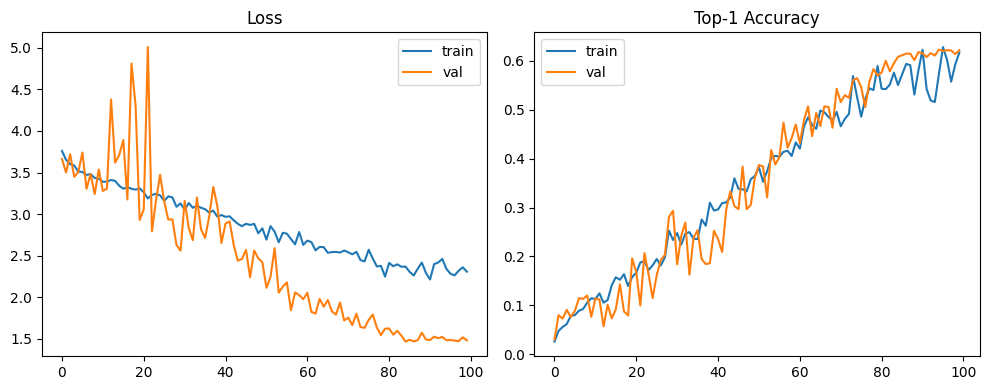

In [16]:
# Fixed params

n_classes = OxfordPetDataset(split="train").get_num_classes()

# Configuration

cfg_B = {
    # Pre-processing's parameters.
    "resize_size": 256,
    "crop_size": 224,

    # Training's parameters.
    "batch_size": 128,
    "num_epochs": 100,

    # Optimizer's parameters.
    "lr": 1e-3,
    "wd": 1e-4,
    "step_size": 5,

    # Batch transformations
    "batch_transforms" : v2.Compose([
        v2.MixUp(alpha=1.0, num_classes=n_classes),
        v2.CutMix(alpha=1.0, num_classes=n_classes),
    ]),

    # Scheduler
    "scheduler":True,

    # Label Smoothing
    "label_smoothing":0.0,

    # Model
    'block_type': ResidualBlock,
    'block_depths': [2, 3, 4, 2],
    'num_classes': n_classes,
    'input_channels': 3,
    'dropout': 0.5
}

# Transform for Data Augmentation and Img Resizing  

mean_image_net = [0.485, 0.456, 0.406]
std_image_net = [0.229, 0.224, 0.225]

train_transformer_B = T.Compose([
    T.RandomResizedCrop(cfg_B["crop_size"], scale=(0.8, 1.0)),  
    T.RandomHorizontalFlip(),   
    T.ToTensor(),
    T.ConvertImageDtype(torch.float),
    T.RandomErasing(p=0.5,   
                    scale=(0.02, 0.33),
                    ratio=(0.3, 3.3),
                    value=0,
                    inplace=False),
    T.Normalize(mean_image_net, std_image_net),
])

test_transformer_B = T.Compose([
    T.Resize(cfg_B["resize_size"]),   
    T.CenterCrop(cfg_B["crop_size"]),
    T.ToTensor(),
    T.Normalize(mean_image_net, std_image_net),
])

# DataLoaders  

train_dl_B, val_dl_B, test_dl_B = get_dataloaders(train_transformer_B,
                                               test_transformer_B,
                                               cfg_B["batch_size"])

# Model  

model_B = CNN(cfg_B['block_type'],
             cfg_B['block_depths'],
             cfg_B['num_classes'],
             cfg_B['input_channels'],
             cfg_B['dropout'])

num_params_B = sum(p.numel() for p in model_B.parameters())

trainer_B = Trainer(
    model=model_B,
    train_loader=train_dl_B,
    val_loader=val_dl_B,
    test_loader=test_dl_B,
    device=device,
    num_classes=n_classes,
    cfg=cfg_B,
    verbose=False,
    model_file_name='model_B'
)

print(summary(model_B))

# Training or Loading  

if TRAINING_REQUIRED:
    
    trainer_B.train()

    trainer_B.save_history()
        
else:
    try:
        trainer_B.load("ckpts/model_B.pth", model_name="model_B")
    except Exception as e:
        print("Model not found or failed to load:", e)

# Evaluation  

test_loss, test_accuracy = trainer_B.eval("test")
print(f"Accuracy on the test set: {test_accuracy:.3f}")

models_performance['model_B'] = {
    'test_accuracy': test_accuracy,
    'num_params': num_params_B,     
    'flag': 'best',
    'label': 'Best Model'
}

history_B_loaded = load_history("plots/history_B.json", history_name="history_B")

plot_history(history_B_loaded)

## Ablation studies on architecture 

We are going to perform ablation studies both on the architecture (trying different depths and different types of convolutional blocks) and on the regularization and training recipes.
Our goal is to see what of the components of our network actually contributed to the high performance we got.

### Model C: a shallow resnet

We want to show what happens when we use a shallow ResNet, with residual blocks (no bottleneck, just like our best model).

Accuracy on the test set: 0.594


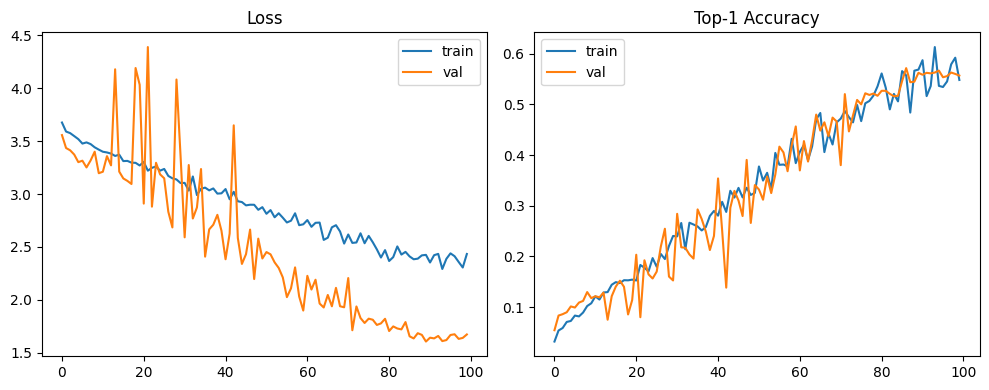

In [18]:
# Configuration  

cfg_C = copy.deepcopy(cfg_B)
cfg_C['block_depths'] = [1,1,1,1]

# DataLoaders  

train_dl_C = copy.deepcopy(train_dl_B)
val_dl_C = copy.deepcopy(val_dl_B)
test_dl_C = copy.deepcopy(test_dl_B)

# Model  

model_C = CNN(cfg_C['block_type'],
             cfg_C['block_depths'],
             cfg_C['num_classes'],
             cfg_C['input_channels'],
             cfg_C['dropout'])

num_params_C = sum(p.numel() for p in model_C.parameters())

trainer_C = Trainer(
    model=model_C,
    train_loader=train_dl_C,
    val_loader=val_dl_C,
    test_loader=test_dl_C,
    device=device,
    num_classes=n_classes,
    cfg=cfg_C,
    verbose=False,
    model_file_name='model_C'
)

# Training or Loading  

if TRAINING_REQUIRED:
    trainer_C.train()
    trainer_C.save_history()
else:
    try:
        trainer_C.load("ckpts/model_C.pth", model_name="model_C")
    except Exception as e:
        print("Model not found or failed to load:", e)
    
# Evaluation  

test_loss, test_accuracy = trainer_C.eval("test")
print(f"Accuracy on the test set: {test_accuracy:.3f}")

models_performance['model_C'] = {
    'test_accuracy': test_accuracy,
    'num_params': num_params_C,     
    'flag': 'architecture',
    'label': 'Shallow ResNet'
}

history_C_loaded = load_history("plots/history_C.json", history_name="history_C")

plot_history(history_C_loaded)

Despite halving the depth of the network, the performance of this shallow net did not drop excessively.

### Model E: BatchNormBlock
We use a variation of modelB where we don't use skip connections.

Accuracy on the test set: 0.558


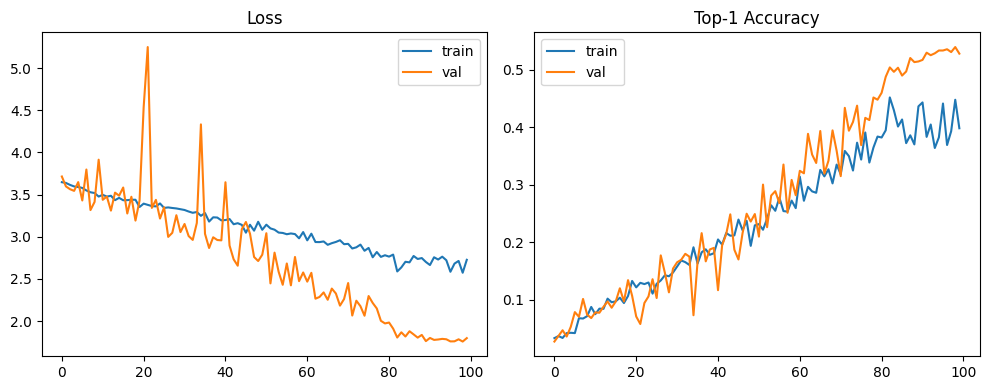

In [20]:
#   Configuration  

cfg_E = copy.deepcopy(cfg_B)
cfg_E['block_type'] = BatchNormBlock

#   DataLoaders  

train_dl_E = copy.deepcopy(train_dl_B)
val_dl_E   = copy.deepcopy(val_dl_B)
test_dl_E  = copy.deepcopy(test_dl_B)

#   Model  

model_E = CNN(cfg_E['block_type'],
             cfg_E['block_depths'],
             cfg_E['num_classes'],
             cfg_E['input_channels'],
             cfg_E['dropout'])

#print(summary(model_E, (1,3,224,224)))
num_params_E = sum(p.numel() for p in model_E.parameters())

trainer_E = Trainer(
    model=model_E,
    train_loader=train_dl_E,
    val_loader=val_dl_E,
    test_loader=test_dl_E,
    device=device,
    num_classes=n_classes,
    cfg=cfg_E,
    verbose=False,
    model_file_name='model_E'
)

#   Training or Loading  

if TRAINING_REQUIRED:
    trainer_E.train()
    trainer_E.save_history()
else:
    try:
        trainer_E.load("ckpts/model_E.pth", model_name="model_E")
    except Exception as e:
        print("Model not found or failed to load:", e)
    
#   Evaluation  

test_loss, test_accuracy = trainer_E.eval("test")
print(f"Accuracy on the test set: {test_accuracy:.3f}")

models_performance['model_E'] = {
    'test_accuracy': test_accuracy,
    'num_params': num_params_E,     
    'flag': 'architecture',
    'label': 'Batch Norm Net'
}

history_E_loaded = load_history("plots/history_E.json", history_name="history_E")

plot_history(history_E_loaded)

### Model F: Bottleneck Block
Even though the BottleneckBlock block outperforms BatchNormBlock, it is no better than the standard ResidualBlock, for this specific task.

Accuracy on the test set: 0.593


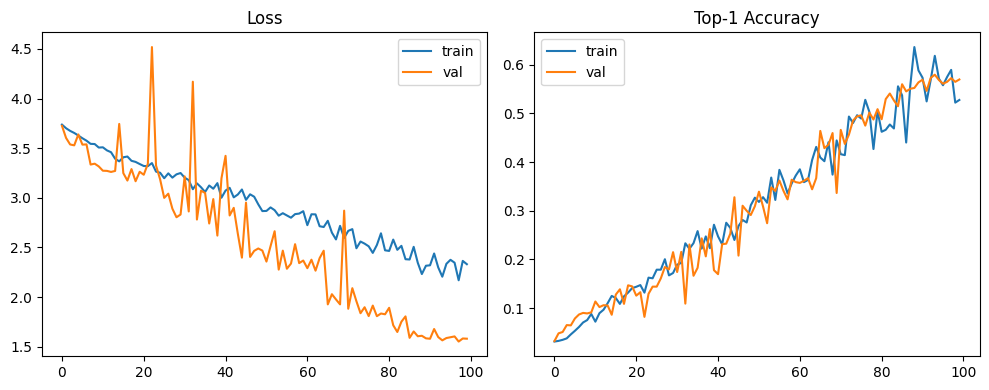

In [22]:
# Configuration  

cfg_F = copy.deepcopy(cfg_B)
cfg_F['block_type'] = Bottleneck

# DataLoaders  

train_dl_F = copy.deepcopy(train_dl_B)
val_dl_F   = copy.deepcopy(val_dl_B)
test_dl_F  = copy.deepcopy(test_dl_B)

# Model  

model_F = CNN(cfg_F['block_type'],
             cfg_F['block_depths'],
             cfg_F['num_classes'],
             cfg_F['input_channels'],
             cfg_F['dropout'])

num_params_F = sum(p.numel() for p in model_F.parameters())

trainer_F = Trainer(
    model=model_F,
    train_loader=train_dl_F,
    val_loader=val_dl_F,
    test_loader=test_dl_F,
    device=device,
    num_classes=n_classes,
    cfg=cfg_F,
    verbose=False,
    model_file_name='model_F'
)

# Training or Loading  

if TRAINING_REQUIRED:
    trainer_F.train()
    trainer_F.save_history()
else:
    try:
        trainer_F.load("ckpts/model_F.pth", model_name="model_F")
    except Exception as e:
        print("Model not found or failed to load:", e)
    
# Evaluation  

test_loss, test_accuracy = trainer_F.eval("test")
print(f"Accuracy on the test set: {test_accuracy:.3f}")

models_performance['model_F'] = {
    'test_accuracy': test_accuracy,
    'num_params': num_params_F,     
    'flag': 'architecture',
    'label': 'Bottleneck'
}

history_F_loaded = load_history("plots/history_F.json", history_name="history_F")

plot_history(history_F_loaded)

## Ablation on generalization and training recipes

We now try to remove some of the training recipes we employed in our best network.

### Model G
We remove MixUp, CutMix, Horizontal Flip, Random Erasing from ModelB.

Accuracy on the test set: 0.616


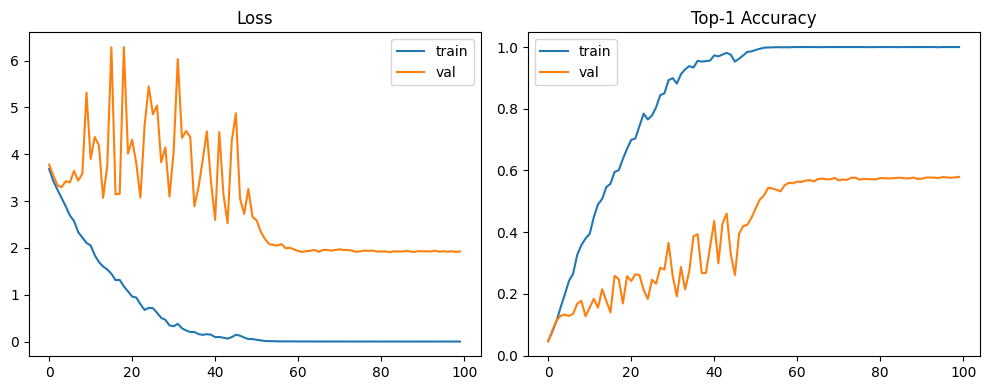

In [25]:
# Configuration  
cfg_G = copy.deepcopy(cfg_B)
cfg_G['batch_transforms'] = None

mean_image_net = [0.485, 0.456, 0.406]
std_image_net = [0.229, 0.224, 0.225]

train_transformer_G = T.Compose([
    T.RandomResizedCrop(cfg_G["crop_size"], scale=(0.8, 1.0)),  
    T.ToTensor(),
    T.Normalize(mean_image_net, std_image_net),
])

test_transformer_G = T.Compose([
    T.Resize(cfg_G["resize_size"]),
    T.CenterCrop(cfg_G["crop_size"]),
    T.ToTensor(),
    T.Normalize(mean_image_net, std_image_net),
])

# DataLoaders  

train_dl_G, val_dl_G, test_dl_G = get_dataloaders(train_transformer_G,
                                               test_transformer_G,
                                               cfg_G["batch_size"])

# Model  

model_G = CNN(cfg_G['block_type'],
             cfg_G['block_depths'],
             cfg_G['num_classes'],
             cfg_G['input_channels'],
             cfg_G['dropout'])

num_params_G = sum(p.numel() for p in model_G.parameters())

trainer_G = Trainer(
    model=model_G,
    train_loader=train_dl_G,
    val_loader=val_dl_G,
    test_loader=test_dl_G,
    device=device,
    num_classes=n_classes,
    cfg=cfg_G,
    verbose=False,
    model_file_name='model_G'
)

# Training or Loading  

if TRAINING_REQUIRED:
    trainer_G.train()
    trainer_G.save_history()
else:
    try:
        trainer_G.load("ckpts/model_G.pth", model_name="model_G")
    except Exception as e:
        print("Model not found or failed to load:", e)
    
# Evaluation  

test_loss, test_accuracy = trainer_G.eval("test")
print(f"Accuracy on the test set: {test_accuracy:.3f}")

models_performance['model_G'] = {
    'test_accuracy': test_accuracy,
    'num_params': num_params_G,     
    'flag': 'recipes',
    'label': 'No augmentation, overfitting'
}

history_G_loaded = load_history("plots/history_G.json", history_name="history_G")

plot_history(history_G_loaded)

### Model H
We remove dropout, scheduler and weight decay.

Accuracy on the test set: 0.528


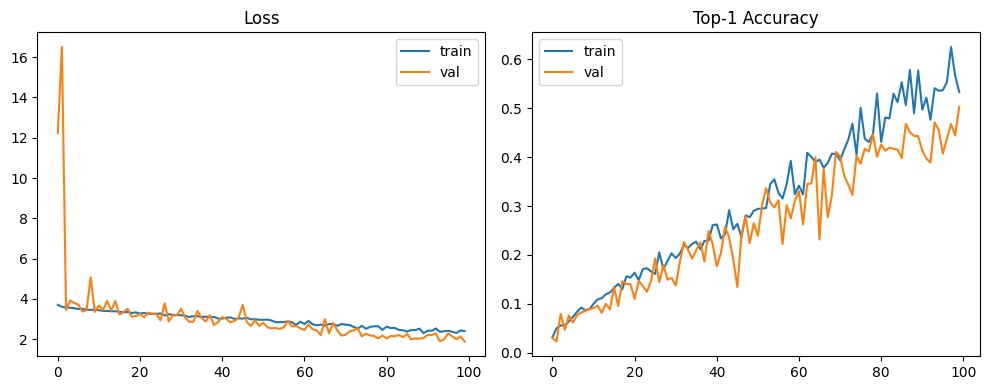

In [28]:
# Fixed params  

n_classes = OxfordPetDataset(split="train").get_num_classes()

# Configuration  

cfg_H = copy.deepcopy(cfg_B)

cfg_H['dropout'] = 0
cfg_H['wd'] = 0.0
cfg_H['scheduler']= False

# DataLoaders  
train_dl_H = copy.deepcopy(train_dl_B)
val_dl_H = copy.deepcopy(val_dl_B)
test_dl_H = copy.deepcopy(test_dl_B)

# Model

model_H = CNN(cfg_H['block_type'],
             cfg_H['block_depths'],
             cfg_H['num_classes'],
             cfg_H['input_channels'],
             cfg_H['dropout'])

num_params_H = sum(p.numel() for p in model_H.parameters())

trainer_H = Trainer(
    model=model_H,
    train_loader=train_dl_H,
    val_loader=val_dl_H,
    test_loader=test_dl_H,
    device=device,
    num_classes=n_classes,
    cfg=cfg_H,
    verbose=False,
    model_file_name='model_H'
)

# Training or Loading  

if TRAINING_REQUIRED:
    trainer_H.train()
    trainer_H.save_history()
else:
    try:
        trainer_H.load("ckpts/model_H.pth", model_name="model_H")
    except Exception as e:
        print("Model not found or failed to load:", e)
    
# Evaluation  

test_loss, test_accuracy = trainer_H.eval("test")
print(f"Accuracy on the test set: {test_accuracy:.3f}")

models_performance['model_H'] = {
    'test_accuracy': test_accuracy,
    'num_params': num_params_H,     
    'flag': 'recipes',
    'label': 'No dropout, no scheduler, no weight decay'
}

history_H_loaded = load_history("plots/history_H.json", history_name="history_H")

plot_history(history_H_loaded)

## Results of Ablation Studies
Removing some parts of the architecture or changing the recipes, the performance drops with respect to our best model (ModelB).

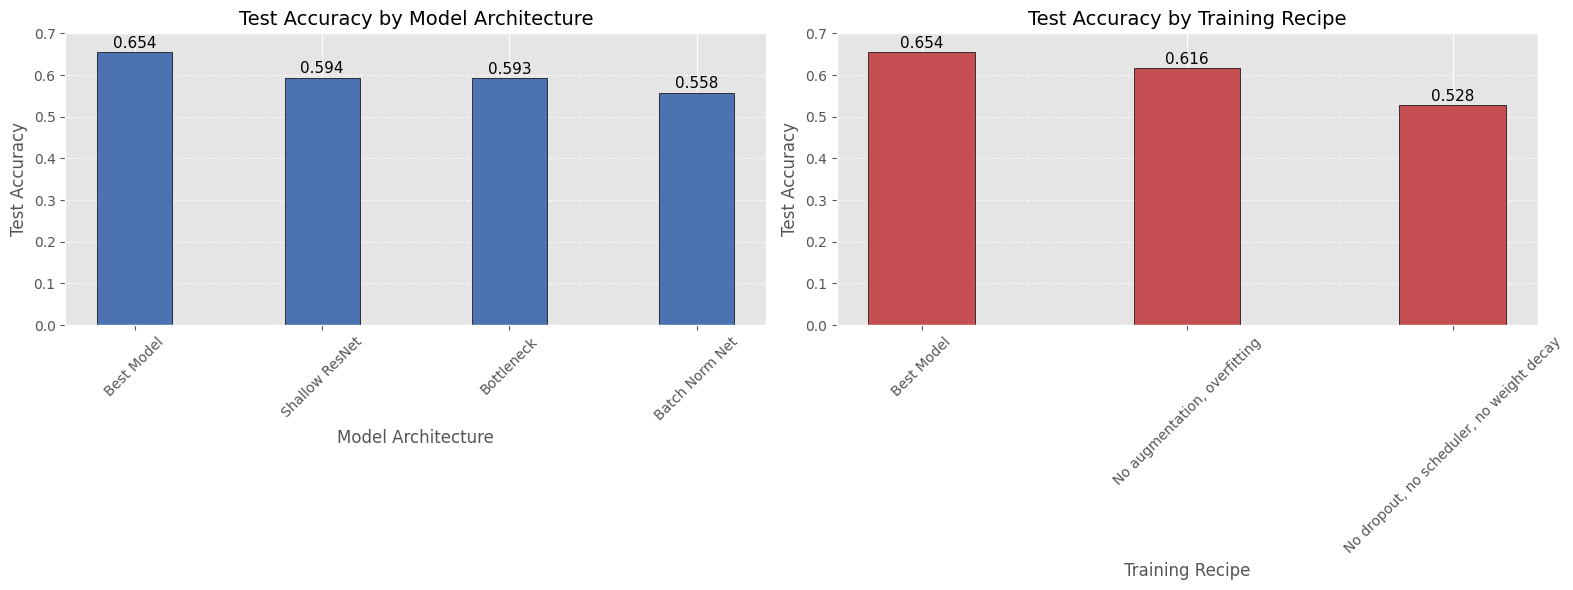

In [32]:
# Separate groups
architecture_group = []
recipes_group = []

for model, data in models_performance.items():
    if data['flag'] == 'architecture' or data['flag'] == 'best':
        architecture_group.append((data['test_accuracy'], data['label']))
    if data['flag'] == 'recipes' or data['flag'] == 'best':
        recipes_group.append((data['test_accuracy'], data['label']))

# Sort by decreasing accuracy
architecture_group = sorted(architecture_group, reverse=True)
recipes_group = sorted(recipes_group, reverse=True)

plt.style.use('ggplot')
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Architecture histogram
accuracies, labels = zip(*architecture_group)
bars = axes[0].bar(labels, accuracies, color='#4c72b0', width=0.4, edgecolor='black')
axes[0].set_xlabel('Model Architecture', fontsize=12)
axes[0].set_ylabel('Test Accuracy', fontsize=12)
axes[0].set_title('Test Accuracy by Model Architecture', fontsize=14)
axes[0].set_ylim(0, 0.7)
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', linestyle='--', alpha=0.7)
for bar, acc in zip(bars, accuracies):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f'{acc:.3f}', ha='center', fontsize=11)

# Recipes histogram
accuracies, labels = zip(*recipes_group)
bars = axes[1].bar(labels, accuracies, color='#c44e52', width=0.4, edgecolor='black')
axes[1].set_xlabel('Training Recipe', fontsize=12)
axes[1].set_ylabel('Test Accuracy', fontsize=12)
axes[1].set_title('Test Accuracy by Training Recipe', fontsize=14)
axes[1].set_ylim(0, 0.7)
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(axis='y', linestyle='--', alpha=0.7)
for bar, acc in zip(bars, accuracies):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f'{acc:.3f}', ha='center', fontsize=11)

plt.tight_layout()
plt.show()

### Pareto curve
We show the Pareto curve to highlight the model performance w.r.t the model complexity.
ModelB was indeed the best one, as it is the only one on the curve (aside from the shallow Res-Net, which is merely a less deep variant of model B).

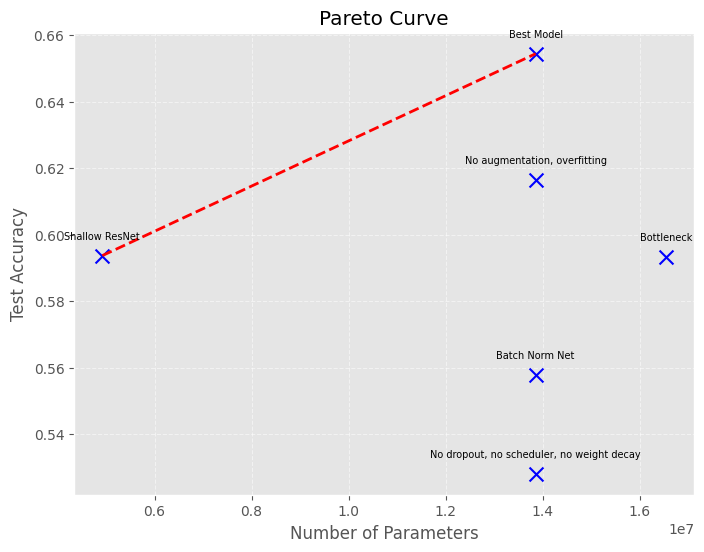

In [33]:
# Collect data for Pareto plot
x_params = []  
y_acc = []     
labels = []

for model, data in models_performance.items():
    if 'num_params' in data and data['test_accuracy'] >= 0.3:
        x_params.append(data['num_params'])
        y_acc.append(data['test_accuracy'])
        labels.append(data['label'])

x_params = np.array(x_params)
y_acc = np.array(y_acc)
labels = np.array(labels)

# Sort by number of parameters and by accuracy descending 
sorted_idx = np.lexsort((-y_acc, x_params))
x_sorted = x_params[sorted_idx]
y_sorted = y_acc[sorted_idx]
labels_sorted = labels[sorted_idx]

# Compute Pareto Curve
pareto_idx = []
max_acc = -np.inf
for xi, yi in zip(x_sorted, y_sorted):
    if yi >= max_acc:
        pareto_idx.append((xi, yi))
        max_acc = yi
pareto_x, pareto_y = zip(*pareto_idx)

# Plot
plt.figure(figsize=(8,6))
plt.scatter(x_params, y_acc, marker='x', s=100, label='Models', color='blue')
plt.plot(pareto_x, pareto_y, 'r--', label='Pareto Front', linewidth=2)

# Annotate with model labels
for xi, yi, label in zip(x_params, y_acc, labels):
    plt.text(xi, yi + 0.005, label, ha='center', fontsize=7, rotation=0)
    
plt.xlabel('Number of Parameters')
plt.ylabel('Test Accuracy')
plt.title('Pareto Curve')
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

# Part 2: fine-tune an existing network

Your goal is to fine-tune a pretrained ResNet-18 model on `OxfordPetDataset`. Use the implementation provided by PyTorch, i.e. the opposite of part 1. Specifically, use the PyTorch ResNet-18 model pretrained on ImageNet-1K (V1). Divide your fine-tuning into two parts:

2A. First, fine-tune the ResNet-18 with the same training hyperparameters you used for your best model in part 1.

2B. Then, tweak the training hyperparameters in order to increase the accuracy on the test split. Justify your choices by analyzing the training plots and/or citing sources that guided you in your decisions — papers, blog posts, YouTube videos, or whatever else you may find useful. You should consider yourselves satisfied once you obtain a classification accuracy on the test split of ~90%.

In [26]:
def get_model(
        num_classes: int,
        weights: Optional[ResNet18_Weights] = None
    ) -> nn.Module:
    """Gets an image classifier based on ResNet-18.

    Args:
        num_classes: the number of classes.
        weights: pretrained weights to load into the network.
                 If None, the network is randomly initialized.

    Returns:
        The required network.
    """
    model = resnet18(weights=weights)
    # Here we override the old classifier
    model.fc = nn.Linear(model.fc.in_features, num_classes)

    return model

def set_requires_grad(layer: torch.nn.Module, train: bool) -> None:
    """Sets the requires_grad attribute to True or False for each parameter within a layer.

        Args:
            layer: the layer to freeze.
            train: if true train the layer.
    """
    for p in layer.parameters():
        p.requires_grad = train

## Fine Tuning ResNet-18 with the same hyperparams: Model 2A

Accuracy on the test set: 0.867


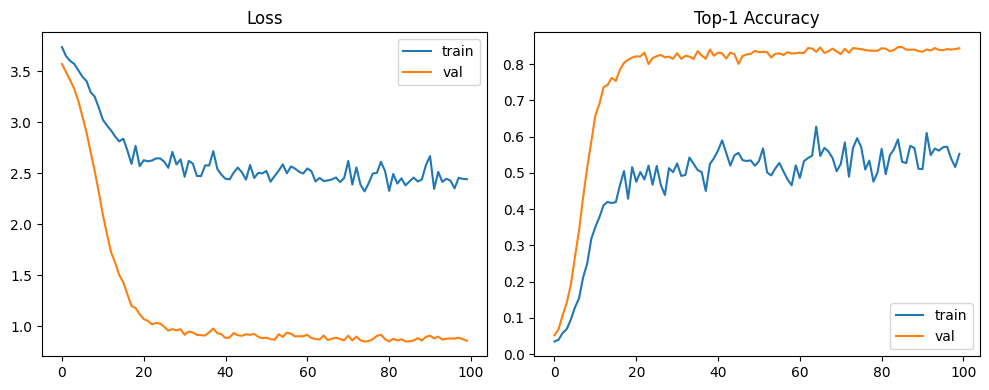

In [29]:
#   Configuration  

cfg_2A = copy.deepcopy(cfg_B)

#   DataLoaders  

train_dl_2A = copy.deepcopy(train_dl_B) 
val_dl_2A = copy.deepcopy(val_dl_B)
test_dl_2A = copy.deepcopy(test_dl_B)

#   Model  

weights = ResNet18_Weights.IMAGENET1K_V1
model_2A = get_model(n_classes, weights).to(device)

set_requires_grad(model_2A.conv1, False)
set_requires_grad(model_2A.bn1, False)
set_requires_grad(model_2A.layer1, False)
set_requires_grad(model_2A.layer2, False)
set_requires_grad(model_2A.layer3, False)
set_requires_grad(model_2A.layer4, False)

trainer_2A = Trainer(
    model=model_2A,
    train_loader=train_dl_2A,
    val_loader=val_dl_2A,
    test_loader=test_dl_2A,
    device=device,
    num_classes=n_classes,
    cfg=cfg_2A,
    verbose=False,
    model_file_name='model_2A'
)

#   Training or Loading  

if TRAINING_REQUIRED:
    trainer_2A.train()
    trainer_2A.save_history()
else:
    try:
        trainer_2A.load("ckpts/model_2A.pth", model_name="model_2A")
    except Exception as e:
        print("Model not found or failed to load:", e)
        
#   Evaluation   
test_loss, test_accuracy = trainer_2A.eval("test")
print(f"Accuracy on the test set: {test_accuracy:.3f}")

history_2A_loaded = load_history("plots/history_2A.json", history_name="history_2A")

plot_history(history_2A_loaded)

### 2B - Tweaking HyperParams for Fine tuning 

We decided to:
* increase the starting learning rate (lr)
* use SGD with momentum instead of AdamW [4]
* reduce epochs
* reduce label smoothing [5]
* add data augmentation
* use a larger size for the input images (320x320 instead of 224x224)
* unfreezing layers during the fine tuning [1][2][3]
* use an adaptive learning rate and weight decay for a better fine tuning [1][2][3]
* change the scheduler using Cosine Annealing + Warmup

Accuracy on the test set: 0.898


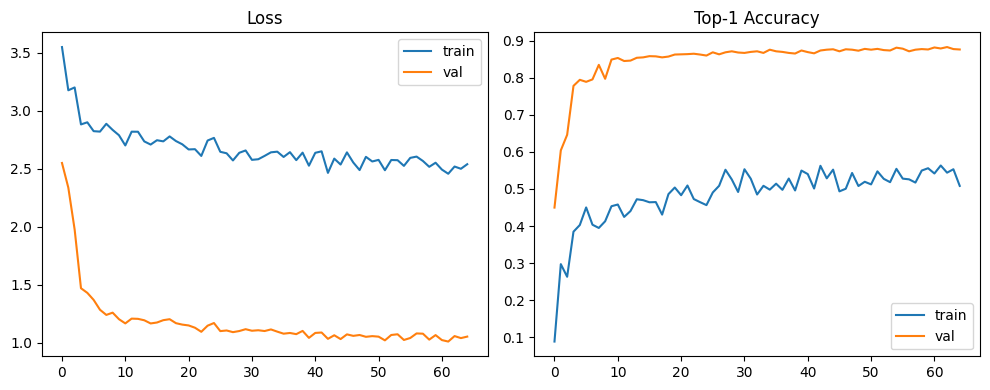

In [31]:
# Copy configuration and dataloaders
cfg_2B = copy.deepcopy(cfg_B)
cfg_2B["lr"] = 0.02       
cfg_2B["wd"] = 1e-4
cfg_2B["num_epochs"] = 65
cfg_2B["label_smoothing"] = 0.05

# Model  
weights = ResNet18_Weights.IMAGENET1K_V1
model_2B = get_model(n_classes, weights).to(device)
mean = weights.meta.get("mean", [0.485, 0.456, 0.406])
std  = weights.meta.get("std",  [0.229, 0.224, 0.225])

# Data Pre-processing and Augmentation  
train_transformer_2B = T.Compose([
    T.RandomResizedCrop(320),
    T.RandomHorizontalFlip(),
    T.RandAugment(num_ops=2, magnitude=10),   # small RandAugment
    T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.15, hue=0.02),
    T.ToTensor(),
    T.Normalize(mean=mean, std=std),
])

test_transformer_2B = T.Compose([
    T.Resize(320),
    T.CenterCrop(320),
    T.ToTensor(),
    T.Normalize(mean=mean, std=std),
])

train_dl_2B, val_dl_2B, test_dl_2B = get_dataloaders(train_transformer_2B,
                                               test_transformer_2B,
                                               cfg_2B["batch_size"])

# Freeze all layers except the head  
set_requires_grad(model_2B.conv1, False)
set_requires_grad(model_2B.bn1, False)
set_requires_grad(model_2B.layer1, False)
set_requires_grad(model_2B.layer2, False)
set_requires_grad(model_2B.layer3, False)
set_requires_grad(model_2B.layer4, False)

unfreeze_schedule = {
    10: [model_2B.layer4, model_2B.layer3],
    20: [model_2B.layer2, model_2B.layer1],
}


optimizer_2B = torch.optim.SGD([
    {'params': model_2B.conv1.parameters(), 'lr': cfg_2B["lr"]*2e-3, 'weight_decay':cfg_2B["wd"]*2e-3},
    {'params': model_2B.bn1.parameters(), 'lr': cfg_2B["lr"]*2e-3, 'weight_decay':cfg_2B["wd"]*2e-3},
    {'params': model_2B.layer1.parameters(), 'lr': cfg_2B["lr"]*5e-3, 'weight_decay':cfg_2B["wd"]*5e-3},
    {'params': model_2B.layer2.parameters(), 'lr': cfg_2B["lr"]*1e-2, 'weight_decay':cfg_2B["wd"]*1e-2},
    {'params': model_2B.layer3.parameters(), 'lr': cfg_2B["lr"]*5e-2, 'weight_decay':cfg_2B["wd"]*5e-2},
    {'params': model_2B.layer4.parameters(), 'lr':  cfg_2B["lr"]*1e-1, 'weight_decay':cfg_2B["wd"]*1e-1},
    {'params': model_2B.fc.parameters(), 'lr': cfg_2B["lr"], 'weight_decay':cfg_2B["wd"]},
],
    momentum=0.9,
    nesterov=True
)

warmup_epochs = 5
main_scheduler = CosineAnnealingLR(optimizer_2B, T_max=cfg_2B["num_epochs"] - warmup_epochs, eta_min=1e-6)
warmup_scheduler = LinearLR(optimizer_2B, start_factor=0.1, total_iters=warmup_epochs)

scheduler_2B = SequentialLR(optimizer_2B, schedulers=[warmup_scheduler, main_scheduler], milestones=[warmup_epochs])

# Trainer  
trainer_2B = Trainer(
    model=model_2B,
    train_loader=train_dl_2B,
    val_loader=val_dl_2B,
    test_loader=test_dl_2B,
    device=device,
    num_classes=n_classes,
    cfg=cfg_2B,
    verbose=True,
    model_file_name='model_2B'
)
trainer_2B.scheduler = scheduler_2B
trainer_2B.optimizer = optimizer_2B

# Training or Loading  

if TRAINING_REQUIRED:
    trainer_2B.fine_tune(unfreeze_schedule)
    trainer_2B.save_history()
else:
    try:
        trainer_2B.load("ckpts/model_2B.pth", model_name="model_2B")
    except Exception as e:
        print("Model not found or failed to load:", e)
        
# Evaluation   
test_loss, test_accuracy = trainer_2B.eval("test")
print(f"Accuracy on the test set: {test_accuracy:.3f}")

history_2B_loaded = load_history("plots/history_2B.json", history_name="history_2B")

plot_history(history_2B_loaded)

## Bibliography
1. Kornblith, S.; Shlens, J.; Le, Q. Do Better ImageNet Models Transfer Better. In Proceedings of the 2019 IEEE/CVF Conference on Computer Vision and Pattern Recognition (CVPR), Long Beach, CA, USA, 16–21 June 2019; pp. 2656–2666.
2. Shin, H.; Roth, H.R.; Gao, M.; Lu, L.; Xu, Z.; Nogues, I.; Yao, J.; Mollura, D.; Summers, R.M. Deep Convolutional Neural Networks for Computer-Aided Detection: CNN Architectures, Dataset Characteristics and Transfer Learning. IEEE Trans. Med. Imaging 2016, 35, 1285–1298. https://doi.org/10.1109/TMI.2016.2528162
3. Yosinski, J.; Clune, J.; Bengio, Y.; Lipson, H. How Transferable are Features in Deep Neural Networks; Ghahramani, Z., Welling, M., Cortes, C., Lawrence, N.D., Weinberger, K.Q., Eds.; Curran Associates, Inc.: Red Hook, NY, USA, 2014; pp. 3320–3328.
4. Keskar, Nitish Shirish, and Richard Socher. "Improving generalization performance by switching from adam to sgd." arXiv preprint arXiv:1712.07628 (2017).
5. Müller, Rafael, Simon Kornblith, and Geoffrey E. Hinton. "When does label smoothing help?." Advances in neural information processing systems 32 (2019).
